# X-CODE CyTOF Debarcoding - Paper Figures

# Imports and Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from matplotlib.colors import TwoSlopeNorm, LogNorm, LinearSegmentedColormap
from collections import Counter
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform
from scipy.stats import hypergeom
import xcode_debarcode as xd
import os

DATA_DIR = '../data/'
OUTPUT_DIR = 'paper_figures/'
os.makedirs(f'{OUTPUT_DIR}/main', exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/supplementary', exist_ok=True)

plt.rcParams.update({'font.size': 10, 'axes.titlesize': 11, 'axes.labelsize': 10,
                     'xtick.labelsize': 9, 'ytick.labelsize': 9, 'legend.fontsize': 9,
                     'figure.dpi': 150})

# 2M expected barcodes 
EXPECTED_BARCODES_2M = {
    "W": {1, 5, 6, 9, 11, 12, 16, 17, 21, 23, 24, 25},
    "Y": {1, 5, 8, 9, 13, 14, 15, 18, 20, 22, 23, 27},
    "Z": {2, 4, 7, 9, 12, 13, 15, 16, 19, 20, 25, 26},
    "J": {1, 2, 3, 5, 10, 11, 12, 16, 21, 23, 26, 27},
}
EXPECTED_COLORS = {"W": "#FF6F61", "Y": "#6B5B95", "Z": "#88B04B", "J": "#FFA500"}

def channels_to_pattern(channels, n_channels=27):
    pattern = ['0'] * n_channels
    for ch in channels:
        pattern[ch - 1] = '1'
    return ''.join(pattern)

EXPECTED_PATTERNS_2M = {name: channels_to_pattern(chs) for name, chs in EXPECTED_BARCODES_2M.items()}
PATTERN_TO_NAME_2M = {v: k for k, v in EXPECTED_PATTERNS_2M.items()}

OTHER_COLOR, DNA_COLOR, NON_DNA_COLOR = "#cccccc", "#2ecc71", "#e74c3c"
METHOD_COLORS = {'pc_gmm': '#3498db', 'premessa': '#e74c3c'}
RATIO_COLORS = {2: '#e74c3c', 5: '#f39c12', 10: '#27ae60', 15: '#3498db', 20: '#9b59b6'}

UNIVERSE_18CH = 126 * 126 

# Simulation code

In [2]:
USE_PRECOMP_SIM = True

In [3]:
# Compares PC-GMM, GMM, PreMessa with/without Hamming clustering
# Outputs: benchmark_summary.csv (metrics), benchmark_curves.csv (ROC curves)
# Set USE_PRECOMP_SIM=True in previous cell to skip simulation and load from CSV

from scipy import stats
from numba import jit
from joblib import Parallel, delayed
import joblib
from tqdm import tqdm
import contextlib
import multiprocessing
import time
import warnings
warnings.filterwarnings('ignore')

import xcode_debarcode as xd

# =============================================================================
# CONFIG
# =============================================================================
CONFIG = {
    'n_cells': 10000,
    'n_channels_list': [18, 27],
    'n_barcodes_list': [1, 3, 5, 10, 30, 100, 500, 1000, 3000],
    'ratio_list': [2, 5, 10, 15, 20],
    'alpha_list': [0.2, 0.5, 1.0, 2.0, 5.0],
    'error_rate_list': [0.01, 0.05, 0.1, 0.15],
    'debarcode_methods': ['pc_gmm', 'gmm', 'premessa'],
    'hamming_methods': ['msg', 'sphere'],
    'n_replicates': 3,
    'random_seed': 42,
    'n_jobs': -1,
    'n_init': 5,
    'premessa_n_iter': 2,
    'roc_thresholds': [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 1.0],
}

# =============================================================================
# VALIDITY CACHE
# =============================================================================
_VALID_18, _VALID_27 = None, None
_PAT_TO_INT, _INT_TO_PAT = {}, {}
_NEXT_INT = 0

def init_validity_cache():
    global _VALID_18, _VALID_27
    _VALID_18 = {''.join(map(str, p.astype(int))) for p in xd.barcode._generate_4_of_9_patterns(n_blocks=2)}
    _VALID_27 = {''.join(map(str, p.astype(int))) for p in xd.barcode._generate_4_of_9_patterns(n_blocks=3)}

def is_valid(pattern, n_ch):
    return pattern in (_VALID_18 if n_ch == 18 else _VALID_27)

def encode(pattern):
    global _NEXT_INT
    if pattern not in _PAT_TO_INT:
        _PAT_TO_INT[pattern] = _NEXT_INT
        _INT_TO_PAT[_NEXT_INT] = pattern
        _NEXT_INT += 1
    return _PAT_TO_INT[pattern]

def encode_batch(patterns):
    return np.array([encode(p) for p in patterns], dtype=np.int32)

# =============================================================================
# NUMBA METRICS
# =============================================================================
@jit(nopython=True, cache=True)
def _basic_counts(gt, pred, valid_mask):
    n_valid, n_correct, n_gt_valid = 0, 0, 0
    for i in range(len(gt)):
        if valid_mask[gt[i]]:
            n_gt_valid += 1
        if valid_mask[pred[i]]:
            n_valid += 1
            if pred[i] == gt[i]:
                n_correct += 1
    return n_correct, n_valid - n_correct, n_gt_valid - n_correct, n_valid, n_correct

@jit(nopython=True, cache=True)
def _basic_counts_subset(gt, pred, valid_mask, idx):
    n_valid, n_correct, n_gt_valid = 0, 0, 0
    for j in range(len(idx)):
        i = idx[j]
        if valid_mask[gt[i]]:
            n_gt_valid += 1
        if valid_mask[pred[i]]:
            n_valid += 1
            if pred[i] == gt[i]:
                n_correct += 1
    return n_correct, n_valid - n_correct, n_gt_valid - n_correct, n_valid, n_correct

@jit(nopython=True, cache=True)
def _bh_metrics(gt, baseline, final):
    beneficial, harmful, neutral, n_remap = 0, 0, 0, 0
    for i in range(len(gt)):
        if baseline[i] != final[i]:
            n_remap += 1
            b_ok, f_ok = baseline[i] == gt[i], final[i] == gt[i]
            if not b_ok and f_ok: beneficial += 1
            elif b_ok and not f_ok: harmful += 1
            else: neutral += 1
    return beneficial, harmful, neutral, n_remap

@jit(nopython=True, cache=True)
def _bh_subset(gt, baseline, final, idx):
    beneficial, harmful, neutral, n_remap = 0, 0, 0, 0
    for j in range(len(idx)):
        i = idx[j]
        if baseline[i] != final[i]:
            n_remap += 1
            b_ok, f_ok = baseline[i] == gt[i], final[i] == gt[i]
            if not b_ok and f_ok: beneficial += 1
            elif b_ok and not f_ok: harmful += 1
            else: neutral += 1
    return beneficial, harmful, neutral, n_remap

@jit(nopython=True, cache=True)
def _bincount(arr, n_bins):
    counts = np.zeros(n_bins, dtype=np.int64)
    for i in range(len(arr)):
        counts[arr[i]] += 1
    return counts

@jit(nopython=True, cache=True)
def _survival_tiers(gt, baseline, final, n_pat):
    gt_c = _bincount(gt, n_pat)
    base_c = _bincount(baseline, n_pat)
    final_c = _bincount(final, n_pat)
    
    detected = [i for i in range(n_pat) if gt_c[i] > 0 and base_c[i] > 0]
    n_det = len(detected)
    if n_det == 0:
        return 1.0, 1.0, 1.0, 1.0, 0
    
    sizes = np.array([base_c[detected[i]] for i in range(n_det)])
    sorted_sizes = np.sort(sizes)
    p25 = sorted_sizes[int(n_det * 0.25)]
    p75 = sorted_sizes[int(n_det * 0.75)]
    
    bot_t, bot_s, mid_t, mid_s, top_t, top_s, total_s = 0, 0, 0, 0, 0, 0, 0
    for i in range(n_det):
        idx, size = detected[i], base_c[detected[i]]
        survived = final_c[idx] > 0
        if survived: total_s += 1
        if size <= p25:
            bot_t += 1
            if survived: bot_s += 1
        elif size > p75:
            top_t += 1
            if survived: top_s += 1
        else:
            mid_t += 1
            if survived: mid_s += 1
    
    return (bot_s/bot_t if bot_t else 1.0, mid_s/mid_t if mid_t else 1.0,
            top_s/top_t if top_t else 1.0, total_s/n_det, n_det)

# =============================================================================
# METRICS
# =============================================================================
def compute_metrics(gt, pred, valid_mask, n_pat, n_cells):
    tp, fp, fn, n_valid, n_correct = _basic_counts(gt, pred, valid_mask)
    prec = tp / max(tp + fp, 1)
    rec = tp / max(tp + fn, 1)
    f1 = 2 * prec * rec / max(prec + rec, 1e-10)
    
    gt_c = _bincount(gt, n_pat)
    pred_c = _bincount(pred, n_pat)
    gt_mask = gt_c > 0
    n_true = gt_mask.sum()
    
    # Spearman
    if n_true > 1:
        gt_vec, pred_vec = gt_c[gt_mask].astype(np.float64), pred_c[gt_mask].astype(np.float64)
        spearman = stats.spearmanr(gt_vec, pred_vec)[0] if np.std(pred_vec) > 0 else np.nan
    else:
        spearman = np.nan
    
    n_detected = ((gt_c > 0) & (pred_c > 0)).sum()
    
    return {
        'accuracy': n_correct / max(n_valid, 1),
        'coverage': n_valid / n_cells,
        'f1': f1, 'precision': prec, 'recall': rec,
        'spearman': spearman,
        'pct_barcodes_detected': n_detected / n_true if n_true else 1.0,
        'n_barcodes_detected': int(n_detected),
        'n_true_barcodes': int(n_true),
    }

def compute_curves(gt, baseline, final, conf, valid_mask, thresholds, n_cells):
    sorted_idx = np.argsort(-conf)
    rows = []
    
    for cov in thresholds:
        n_keep = min(int(np.ceil(cov * n_cells)), n_cells)
        if n_keep == 0:
            rows.append({'selection_frac': cov, 'baseline_coverage': 0, 'baseline_accuracy': 1.0,
                        'final_coverage': 0, 'final_accuracy': 1.0})
            continue
        
        idx = sorted_idx[:n_keep].astype(np.int32)
        
        b_tp, _, _, b_valid, b_correct = _basic_counts_subset(gt, baseline, valid_mask, idx)
        f_tp, _, _, f_valid, f_correct = _basic_counts_subset(gt, final, valid_mask, idx)
        
        rows.append({
            'selection_frac': cov,
            'baseline_coverage': b_valid / n_cells,
            'baseline_accuracy': b_correct / max(b_valid, 1),
            'final_coverage': f_valid / n_cells,
            'final_accuracy': f_correct / max(f_valid, 1),
        })
    return rows

def compute_auc(thresholds, values):
    auc = np.trapezoid(values, thresholds)
    return auc / (thresholds[-1] - thresholds[0]) if thresholds[-1] > thresholds[0] else auc

# =============================================================================
# JOBLIB + TQDM
# =============================================================================
@contextlib.contextmanager
def tqdm_joblib(tqdm_obj):
    class TqdmCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_obj.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)
    old = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmCallback
    try:
        yield tqdm_obj
    finally:
        joblib.parallel.BatchCompletionCallBack = old
        tqdm_obj.close()

# =============================================================================
# SINGLE SIMULATION
# =============================================================================
def run_simulation(params):
    n_ch = params['n_channels']
    n_bc = params['n_barcodes']
    err = params['error_rate']
    alpha = params['alpha']
    rep = params['replicate']
    seed = params['seed']
    sim_id = params['sim_id']
    n_cells = CONFIG['n_cells']
    thresholds = np.array(CONFIG['roc_thresholds'])
    
    summary_rows, curve_rows = [], []
    
    # Simulate
    adata = xd.simulate.simulate_cytof_barcodes(
        n_cells=n_cells, n_channels=n_ch, n_barcodes=n_bc, alpha=alpha,
        target_error_rate=err, unbarcoded_fraction=0.0, random_seed=seed, verbose=False)
    
    gt = encode_batch(adata.obs['ground_truth_pattern'].values.astype(str))
    
    # Validity mask
    max_code = max(_PAT_TO_INT.values()) + 1
    valid_mask = np.zeros(max_code + 1000, dtype=np.bool_)
    for pat, code in _PAT_TO_INT.items():
        valid_mask[code] = is_valid(pat, n_ch)
    
    adata = xd.preprocessing.transform(adata, method='log', verbose=False)
    
    # Cache debarcoding
    db_cache = {}
    for method in CONFIG['debarcode_methods']:
        adata_db = adata.copy()
        if method == 'premessa':
            adata_db = xd.debarcode.debarcode(adata_db, method=method, layer='log',
                                               n_iter=CONFIG['premessa_n_iter'], verbose=False)
        else:
            adata_db = xd.debarcode.debarcode(adata_db, method=method, layer='log',
                                               n_init=CONFIG['n_init'], verbose=False)
        
        base_pat = adata_db.obs[f'{method}_assignment'].values.astype(str)
        base_conf = adata_db.obs[f'{method}_confidence'].values.astype(np.float64)
        
        for p in np.unique(base_pat):
            if p not in _PAT_TO_INT:
                code = encode(p)
                if code >= len(valid_mask):
                    valid_mask = np.concatenate([valid_mask, np.zeros(1000, dtype=np.bool_)])
                valid_mask[code] = is_valid(p, n_ch)
        
        base_enc = encode_batch(base_pat)
        n_pat = max(gt.max(), base_enc.max()) + 1
        if len(valid_mask) < n_pat:
            valid_mask = np.concatenate([valid_mask, np.zeros(n_pat - len(valid_mask) + 100, dtype=np.bool_)])
        
        db_cache[method] = {
            'adata': adata_db, 'base_enc': base_enc, 'base_conf': base_conf,
            'base_metrics': compute_metrics(gt, base_enc, valid_mask, n_pat, n_cells)
        }
    
    # Hamming clustering
    for method in CONFIG['debarcode_methods']:
        cache = db_cache[method]
        base_enc, base_conf = cache['base_enc'], cache['base_conf']
        base_m = cache['base_metrics']
        
        for h_method in CONFIG['hamming_methods']:
            for ratio in CONFIG['ratio_list']:
                eval_key = f"{sim_id}_{method}_{h_method}_{ratio}"
                
                adata_hc = xd.postprocessing.hamming_cluster(
                    cache['adata'], f'{method}_assignment', f'{method}_confidence',
                    method=h_method, ratio=float(ratio), layer='log', verbose=False, inplace=False)
                
                final_pat = adata_hc.obs[f'{method}_hamming_assignment'].values.astype(str)
                for p in np.unique(final_pat):
                    if p not in _PAT_TO_INT:
                        code = encode(p)
                        if code >= len(valid_mask):
                            valid_mask = np.concatenate([valid_mask, np.zeros(1000, dtype=np.bool_)])
                        valid_mask[code] = is_valid(p, n_ch)
                
                final_enc = encode_batch(final_pat)
                n_pat = max(gt.max(), base_enc.max(), final_enc.max()) + 1
                if len(valid_mask) < n_pat:
                    valid_mask = np.concatenate([valid_mask, np.zeros(n_pat - len(valid_mask) + 100, dtype=np.bool_)])
                
                final_m = compute_metrics(gt, final_enc, valid_mask, n_pat, n_cells)
                beneficial, harmful, neutral, n_remap = _bh_metrics(gt, base_enc, final_enc)
                surv_b, surv_m, surv_t, surv_o, n_det = _survival_tiers(gt, base_enc, final_enc, n_pat)
                
                curves = compute_curves(gt, base_enc, final_enc, base_conf, valid_mask, thresholds, n_cells)
                base_auc = compute_auc(thresholds, np.array([c['baseline_accuracy'] for c in curves]))
                final_auc = compute_auc(thresholds, np.array([c['final_accuracy'] for c in curves]))
                
                summary_rows.append({
                    'sim_id': sim_id, 'eval_key': eval_key,
                    'n_channels': n_ch, 'n_barcodes': n_bc, 'target_error_rate': err,
                    'alpha': alpha, 'replicate': rep, 'seed': seed,
                    'debarcode_method': method, 'hamming_method': h_method, 'ratio': ratio,
                    # Baseline
                    'baseline_accuracy': base_m['accuracy'], 'baseline_coverage': base_m['coverage'],
                    'baseline_f1': base_m['f1'], 'baseline_precision': base_m['precision'],
                    'baseline_recall': base_m['recall'], 'baseline_spearman': base_m['spearman'],
                    'baseline_pct_barcodes_detected': base_m['pct_barcodes_detected'],
                    'baseline_auc': base_auc, 'n_true_barcodes': base_m['n_true_barcodes'],
                    # Final
                    'final_accuracy': final_m['accuracy'], 'final_coverage': final_m['coverage'],
                    'final_f1': final_m['f1'], 'final_precision': final_m['precision'],
                    'final_recall': final_m['recall'], 'final_spearman': final_m['spearman'],
                    'final_pct_barcodes_detected': final_m['pct_barcodes_detected'],
                    'final_auc': final_auc,
                    # Deltas
                    'accuracy_delta': final_m['accuracy'] - base_m['accuracy'],
                    'f1_delta': final_m['f1'] - base_m['f1'],
                    'spearman_delta': final_m['spearman'] - base_m['spearman'],
                    'pct_barcodes_detected_delta': final_m['pct_barcodes_detected'] - base_m['pct_barcodes_detected'],
                    'auc_delta': final_auc - base_auc,
                    # B/H
                    'beneficial': beneficial, 'harmful': harmful, 'neutral': neutral,
                    'n_remapped': n_remap, 'bh_ratio': beneficial / max(harmful, 1),
                    # Survival
                    'survival_bottom25': surv_b, 'survival_middle50': surv_m,
                    'survival_top25': surv_t, 'survival_overall': surv_o,
                })
                
                for c in curves:
                    curve_rows.append({
                        'sim_id': sim_id, 'eval_key': eval_key,
                        'n_channels': n_ch, 'n_barcodes': n_bc, 'target_error_rate': err,
                        'alpha': alpha, 'replicate': rep,
                        'debarcode_method': method, 'hamming_method': h_method, 'ratio': ratio,
                        **c
                    })
    
    return summary_rows, curve_rows

# =============================================================================
# RUN BENCHMARK
# =============================================================================
def run_benchmark():
    print("Initializing...")
    init_validity_cache()
    print(f"  18ch: {len(_VALID_18):,} patterns | 27ch: {len(_VALID_27):,} patterns")
    
    n_jobs = CONFIG['n_jobs'] if CONFIG['n_jobs'] != -1 else multiprocessing.cpu_count()
    
    # Build params
    params = []
    sim_id = 0
    for n_ch in CONFIG['n_channels_list']:
        max_bc = 126 ** (n_ch // 9)
        for n_bc in CONFIG['n_barcodes_list']:
            if n_bc > max_bc:
                continue
            alphas = [1.0] if n_bc == 1 else CONFIG['alpha_list']
            for err in CONFIG['error_rate_list']:
                for alpha in alphas:
                    for rep in range(CONFIG['n_replicates']):
                        seed = CONFIG['random_seed'] + hash((n_ch, n_bc, err, alpha, rep)) % 10000
                        params.append({'n_channels': n_ch, 'n_barcodes': n_bc, 'error_rate': err,
                                       'alpha': alpha, 'replicate': rep, 'seed': seed, 'sim_id': sim_id})
                        sim_id += 1
    
    n_sims = len(params)
    n_evals = n_sims * len(CONFIG['debarcode_methods']) * len(CONFIG['hamming_methods']) * len(CONFIG['ratio_list'])
    print(f"Simulations: {n_sims:,} | Evaluations: {n_evals:,}")
    
    # Warm up numba
    d = np.array([0, 1, 2], dtype=np.int32)
    _ = _basic_counts(d, d, np.array([True, True, True]))
    _ = _bh_metrics(d, d, d)
    
    start = time.time()
    with tqdm_joblib(tqdm(desc="Simulations", total=n_sims, ncols=100)):
        results = Parallel(n_jobs=n_jobs, backend='loky')(delayed(run_simulation)(p) for p in params)
    
    all_summary, all_curves = [], []
    for s, c in results:
        all_summary.extend(s)
        all_curves.extend(c)
    
    print(f"Done in {time.time() - start:.1f}s")
    return pd.DataFrame(all_summary), pd.DataFrame(all_curves)

# =============================================================================
# MAIN
# =============================================================================
if not USE_PRECOMP_SIM:
    df_summary, df_curves = run_benchmark()
    
    df_summary.to_csv(f'{DATA_DIR}/simulation_results/benchmark_summary.csv', index=False)
    df_curves.to_csv(f'{DATA_DIR}/simulation_results/benchmark_curves.csv', index=False)
    
    print(f"\nSaved: benchmark_summary.csv ({len(df_summary):,} rows)")
    print(f"Saved: benchmark_curves.csv ({len(df_curves):,} rows)")
    
    # Summary
    print("\n--- BY METHOD (baseline) ---")
    for m in sorted(df_summary['debarcode_method'].unique()):
        s = df_summary[df_summary['debarcode_method'] == m]
        print(f"{m:<10} F1={s['baseline_f1'].mean():.3f} AUC={s['baseline_auc'].mean():.3f}")

# Shared Utility Functions

In [4]:
def add_panel_label(ax, label):
    ax.text(-0.12, 1.05, f'{label})', transform=ax.transAxes, fontsize=14, fontweight='bold', va='top')

def compute_ctv(assignments, pattern_to_name):
    """Conditional Total Variation for expected barcodes."""
    counts = {name: sum(1 for p in assignments if pattern_to_name.get(p) == name) 
              for name in ['W', 'Y', 'Z', 'J']}
    n_expected = sum(counts.values())
    if n_expected == 0:
        return np.nan
    p_star = np.array([counts[n] / n_expected for n in ['W', 'Y', 'Z', 'J']])
    return 0.5 * np.sum(np.abs(p_star - 0.25))

def plot_rank_count(ax, assignments, pattern_to_name, expected_colors, top_n=50, 
                    show_legend=False, panel_label=None, ylim=None, extra_stats=None):
    """Rank-count histogram with expected barcodes highlighted."""
    counts = Counter(assignments)
    sorted_patterns = sorted(counts.items(), key=lambda x: -x[1])[:top_n]
    ranks = np.arange(1, len(sorted_patterns) + 1)
    abundances = [c for _, c in sorted_patterns]
    
    bar_colors = [expected_colors.get(pattern_to_name.get(p), OTHER_COLOR) for p, _ in sorted_patterns]
    ax.bar(ranks, abundances, color=bar_colors, width=1.0, edgecolor='none')
    ax.set_yscale('log')
    ax.set_xlabel('Rank')
    ax.set_ylabel('Cell Count')
    ax.set_xlim(0, top_n + 1)
    if ylim:
        ax.set_ylim(ylim)
    ax.grid(True, alpha=0.3, axis='y')
    
    if show_legend:
        legend_elements = [Patch(facecolor=expected_colors[n], label=n) for n in expected_colors]
        legend_elements.append(Patch(facecolor=OTHER_COLOR, label='Other'))
        ax.legend(handles=legend_elements, loc='upper right', fontsize=8, ncol=2)
    
    # Stats
    n_total = len(assignments)
    n_expected = sum(1 for p in assignments if p in pattern_to_name)
    frac = n_expected / n_total if n_total else 0
    ctv = compute_ctv(assignments, pattern_to_name)
    n_detected = len(set(p for p in assignments if p in pattern_to_name))
    
    stats_text = f"% in expected: {frac:.1%}\nExpected detected: {n_detected}/4\nCTV: {ctv:.3f}"
    if extra_stats:
        stats_text += f"\nΔ% in expected: {extra_stats:+.1%}"
    ax.text(0.98, 0.65, stats_text, transform=ax.transAxes, fontsize=10, va='top', ha='right',
            fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='grey'))
    
    if panel_label:
        add_panel_label(ax, panel_label)
    return max(abundances) if abundances else 1

def plot_hamming_heatmap(ax, adata, assignment_col, hamming_radius=4, min_count=50, panel_label=None):
    """Hamming distance heatmap with hierarchical clustering."""
    counts = Counter(adata.obs[assignment_col].values)
    filtered = {p: c for p, c in counts.items() if c >= min_count}
    sorted_patterns = sorted(filtered.items(), key=lambda x: -x[1])
    patterns = [p for p, _ in sorted_patterns]
    n = len(patterns)
    
    if n < 2:
        ax.text(0.5, 0.5, f'Not enough patterns (need ≥2 with count≥{min_count})',
                ha='center', va='center', transform=ax.transAxes)
        return
    
    # Distance matrix
    dist_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(i+1, n):
            d = sum(a != b for a, b in zip(patterns[i], patterns[j]))
            dist_matrix[i, j] = dist_matrix[j, i] = d
    

    order = leaves_list(linkage(squareform(dist_matrix), method='average'))
    patterns = [patterns[i] for i in order]
    dist_matrix = dist_matrix[order, :][:, order]

    
    grey_value = hamming_radius + 1
    display = np.where(dist_matrix > hamming_radius, grey_value, dist_matrix)
    
    r_norm = hamming_radius / grey_value
    colors_positions = [(0.0, '#ffffff'), (0.2*r_norm, '#e8f4f8'), (0.4*r_norm, '#a8d8ea'),
                        (0.6*r_norm, '#6eb5d0'), (0.8*r_norm, '#3d8fb3'), (r_norm, '#1e5a7d'),
                        (r_norm+0.001, '#e5ecf6'), (1.0, '#e5ecf6')]
    cmap = LinearSegmentedColormap.from_list('hamming', list(zip([p for p,c in colors_positions], 
                                                                  [c for p,c in colors_positions])))
    
    im = ax.imshow(display, cmap=cmap, aspect='auto', vmin=0, vmax=grey_value)
    
    # Mark expected barcodes
    for i, p in enumerate(patterns):
        if p in PATTERN_TO_NAME_2M:
            color = EXPECTED_COLORS[PATTERN_TO_NAME_2M[p]]
            ax.axhline(y=i, color=color, linewidth=2.5, alpha=0.8)
            ax.axvline(x=i, color=color, linewidth=2.5, alpha=0.8)
    
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel(f'Barcode (count ≥ {min_count})')
    ax.set_ylabel(f'Barcode (count ≥ {min_count})')
    
    cbar = plt.colorbar(im, ax=ax, shrink=0.7, pad=0.02)
    cbar.set_label('Hamming Distance')
    cbar.set_ticks(list(range(hamming_radius + 1)) + [grey_value])
    cbar.set_ticklabels(list(range(hamming_radius + 1)) + [f'>{hamming_radius}'])
    
    if panel_label:
        add_panel_label(ax, panel_label)

def save_figure(fig, base_path):
    """Save figure in multiple formats."""
    for ext in ['png', 'pdf', 'svg']:
        fig.savefig(f'{base_path}.{ext}', dpi=300, bbox_inches='tight', facecolor='white')

# Main

## 2M sample (Fig1)

Channel mapping complete
  Barcode channels: 27 (stored in adata.uns['barcode_channels'])
  Other channels: 22
  Total channels: 49
Intensity filtering: method=ellipsoidal, layer=log
  Channel sum: min=2.83, max=147.96, mean=85.69
  Channel var: min=0.1411, max=7.37, mean=2.21
  Using robust Mahalanobis distance (percentile=95.0)
  Mahalanobis threshold: 3.15
  Center: sum=88.96, var=2.2416
  Pass: 32367/34071 cells (95.0%)
  [+] Filtered to 32367 cells
  [+] Metadata saved: adata.uns['intensity_filtering']['intensity']


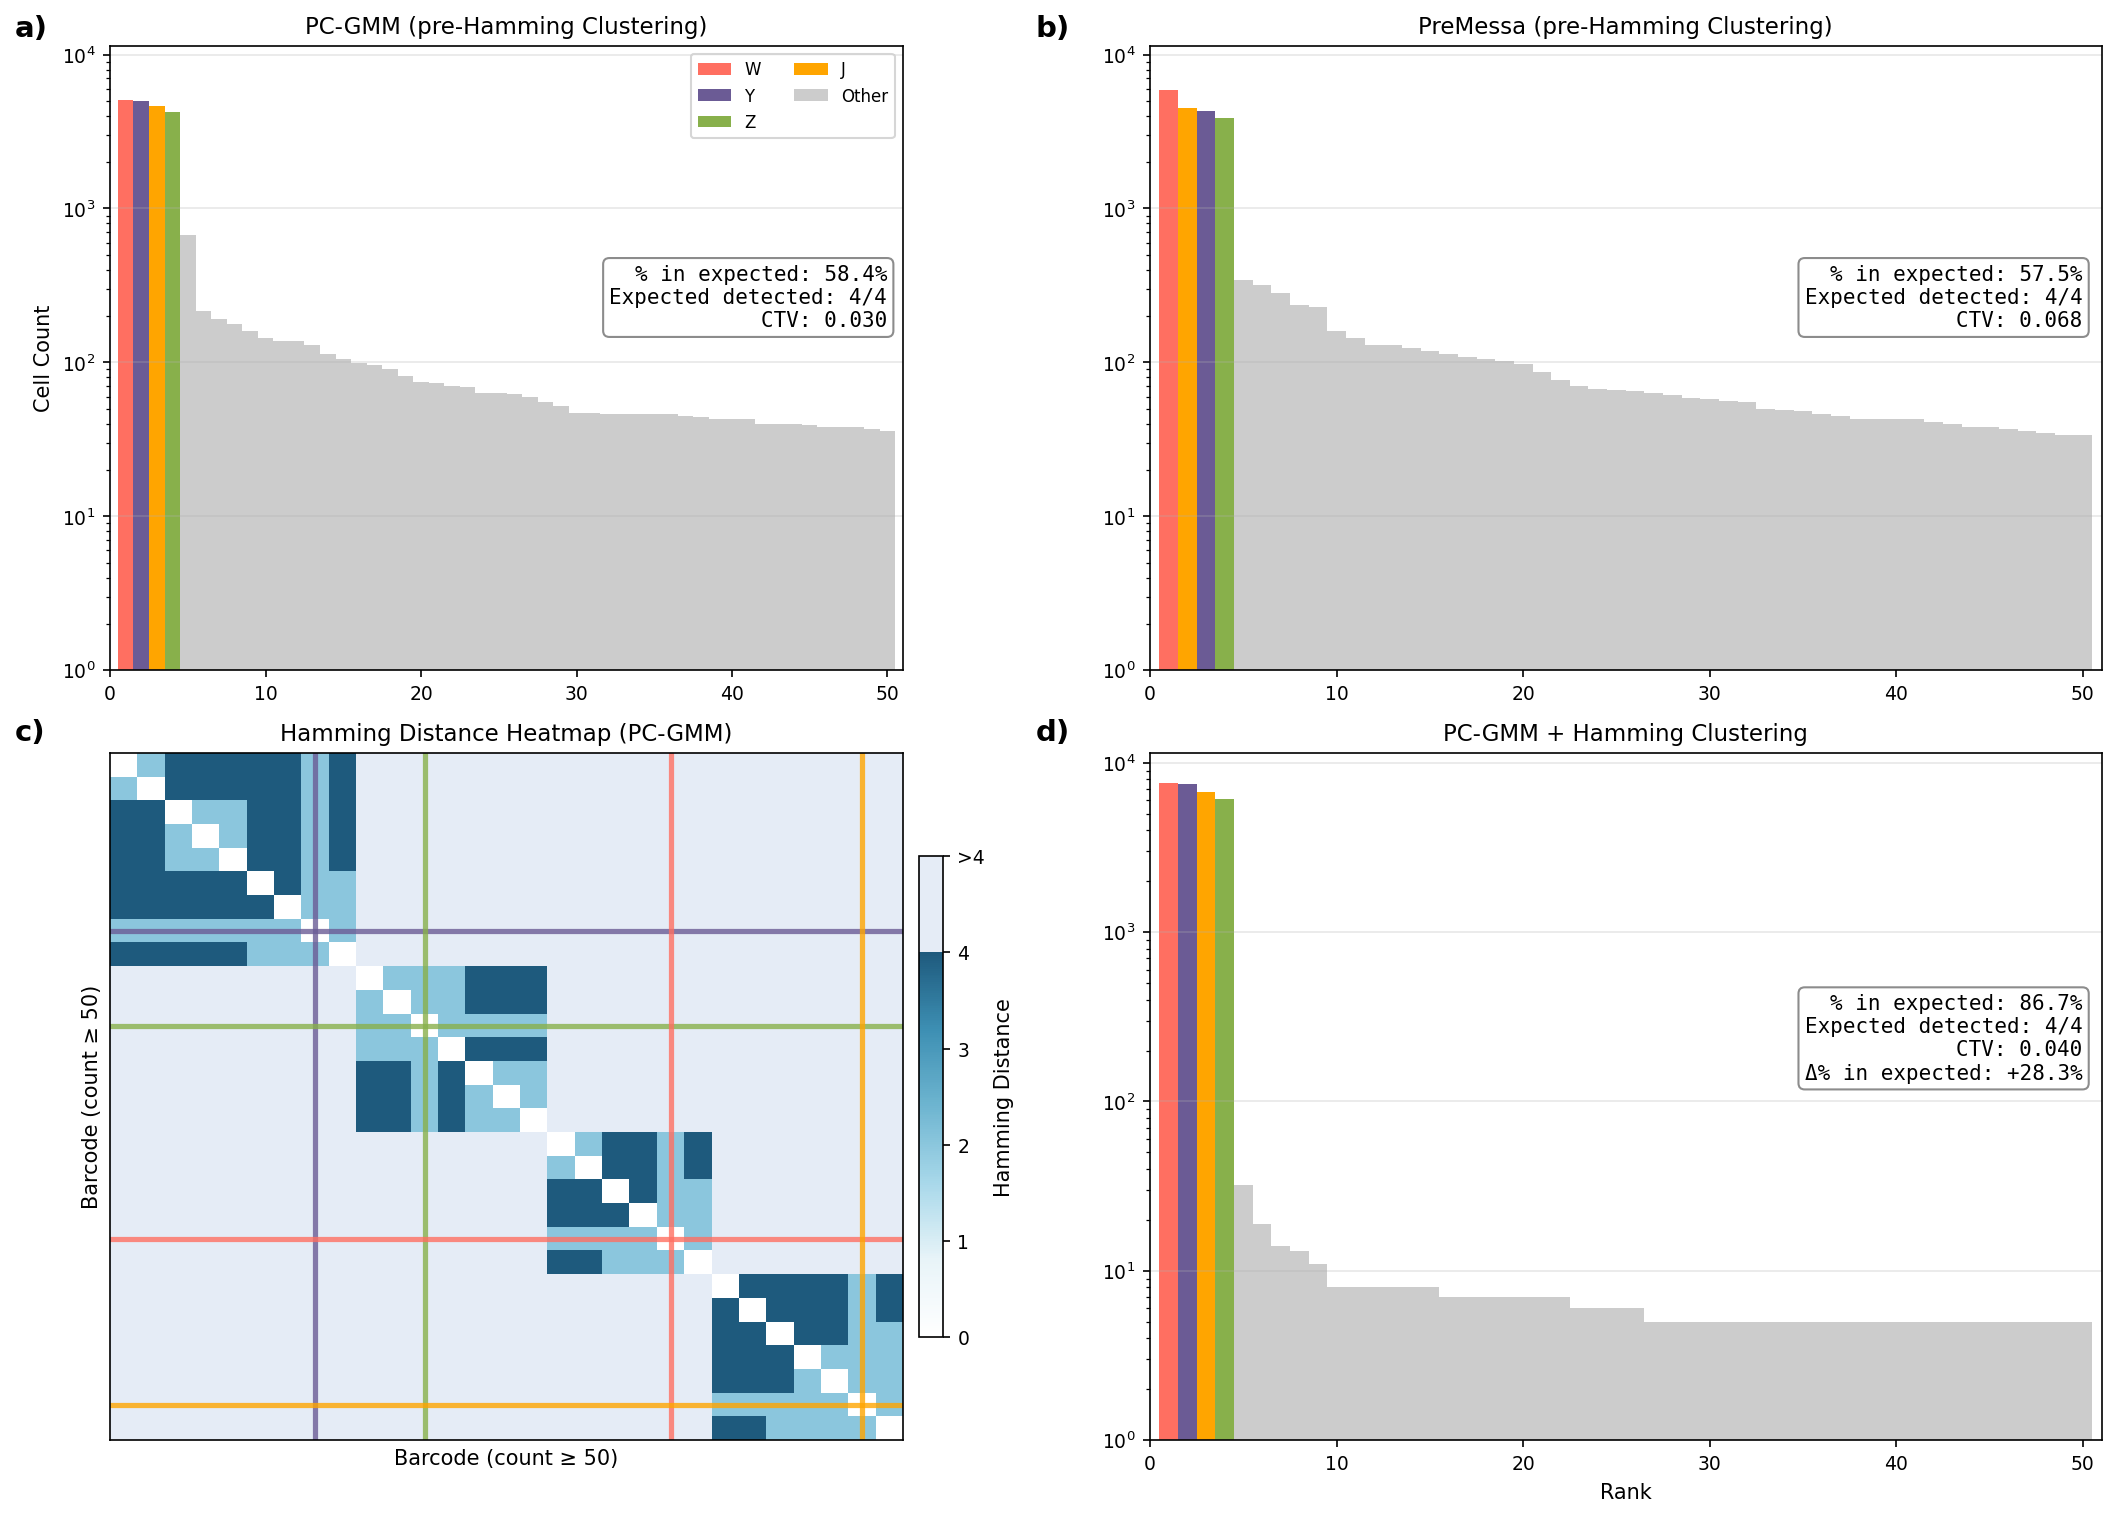

In [5]:
adata_2m = xd.io.read_data(f'{DATA_DIR}/2M_test.fcs')
adata_2m = xd.io.map_channels(adata_2m, f'{DATA_DIR}/barcode_channel_mapping_27ch.csv')
adata_2m = xd.preprocessing.transform(adata_2m, "log", verbose=False)
adata_2m = xd.preprocessing.filter_cells_intensity(adata_2m, layer='log', method='ellipsoidal',
                                                    percentile=95.0, filter_or_flag='filter')

adata_2m = xd.debarcode.debarcode(adata_2m, method='pc_gmm', layer='log', verbose=False)
adata_2m = xd.postprocessing.hamming_cluster(adata_2m, assignment_col='pc_gmm_assignment',
                                              confidence_col='pc_gmm_confidence', method='sphere',
                                              radius=4, ratio=2.0, min_count_center=500, layer='log', verbose=False)
adata_2m = xd.debarcode.debarcode(adata_2m, method='premessa', layer='log', verbose=False)

pre = adata_2m.obs['pc_gmm_assignment'].values
post = adata_2m.obs['pc_gmm_hamming_assignment'].values
pre_pct = sum(1 for p in pre if p in PATTERN_TO_NAME_2M) / len(pre)
post_pct = sum(1 for p in post if p in PATTERN_TO_NAME_2M) / len(post)
gained_pct = post_pct - pre_pct

all_counts = [Counter(adata_2m.obs[col].values) for col in ['pc_gmm_assignment', 'premessa_assignment', 'pc_gmm_hamming_assignment']]
max_count = max(max(c.values()) for c in all_counts)
ylim = (1, max_count * 1.5)

fig1 = plt.figure(figsize=(14, 10), constrained_layout=True)
gs = gridspec.GridSpec(2, 2, figure=fig1, width_ratios=[1, 1.2], height_ratios=[1, 1.1])

ax1a = fig1.add_subplot(gs[0, 0])
plot_rank_count(ax1a, adata_2m.obs['pc_gmm_assignment'].values, PATTERN_TO_NAME_2M, EXPECTED_COLORS,
                show_legend=True, panel_label='a', ylim=ylim)
ax1a.set_title('PC-GMM (pre-Hamming Clustering)')
ax1a.set_xlabel('')

ax1b = fig1.add_subplot(gs[0, 1])
plot_rank_count(ax1b, adata_2m.obs['premessa_assignment'].values, PATTERN_TO_NAME_2M, EXPECTED_COLORS,
                panel_label='b', ylim=ylim)
ax1b.set_title('PreMessa (pre-Hamming Clustering)')
ax1b.set_xlabel('')
ax1b.set_ylabel('')

ax1c = fig1.add_subplot(gs[1, 0])
plot_hamming_heatmap(ax1c, adata_2m, 'pc_gmm_assignment', panel_label='c')
ax1c.set_title('Hamming Distance Heatmap (PC-GMM)')

ax1d = fig1.add_subplot(gs[1, 1])
plot_rank_count(ax1d, adata_2m.obs['pc_gmm_hamming_assignment'].values, PATTERN_TO_NAME_2M, EXPECTED_COLORS,
                panel_label='d', ylim=ylim, extra_stats=gained_pct)
ax1d.set_title('PC-GMM + Hamming Clustering')
ax1d.set_ylabel('')

save_figure(fig1, f'{OUTPUT_DIR}/main/fig1_2M_hamming_clustering')
plt.show()

## 15K sample (Fig2)

Channel mapping complete
  Barcode channels: 18 (stored in adata.uns['barcode_channels'])
  Other channels: 24
  Total channels: 42
Intensity filtering: method=ellipsoidal, layer=log
  Channel sum: min=5.65, max=128.49, mean=76.60
  Channel var: min=0.1012, max=8.87, mean=2.26
  Using robust Mahalanobis distance (percentile=90.0)
  Mahalanobis threshold: 2.68
  Center: sum=78.76, var=2.2240
  Pass: 29851/33168 cells (90.0%)
  [+] Filtered to 29851 cells
  [+] Metadata saved: adata.uns['intensity_filtering']['intensity']


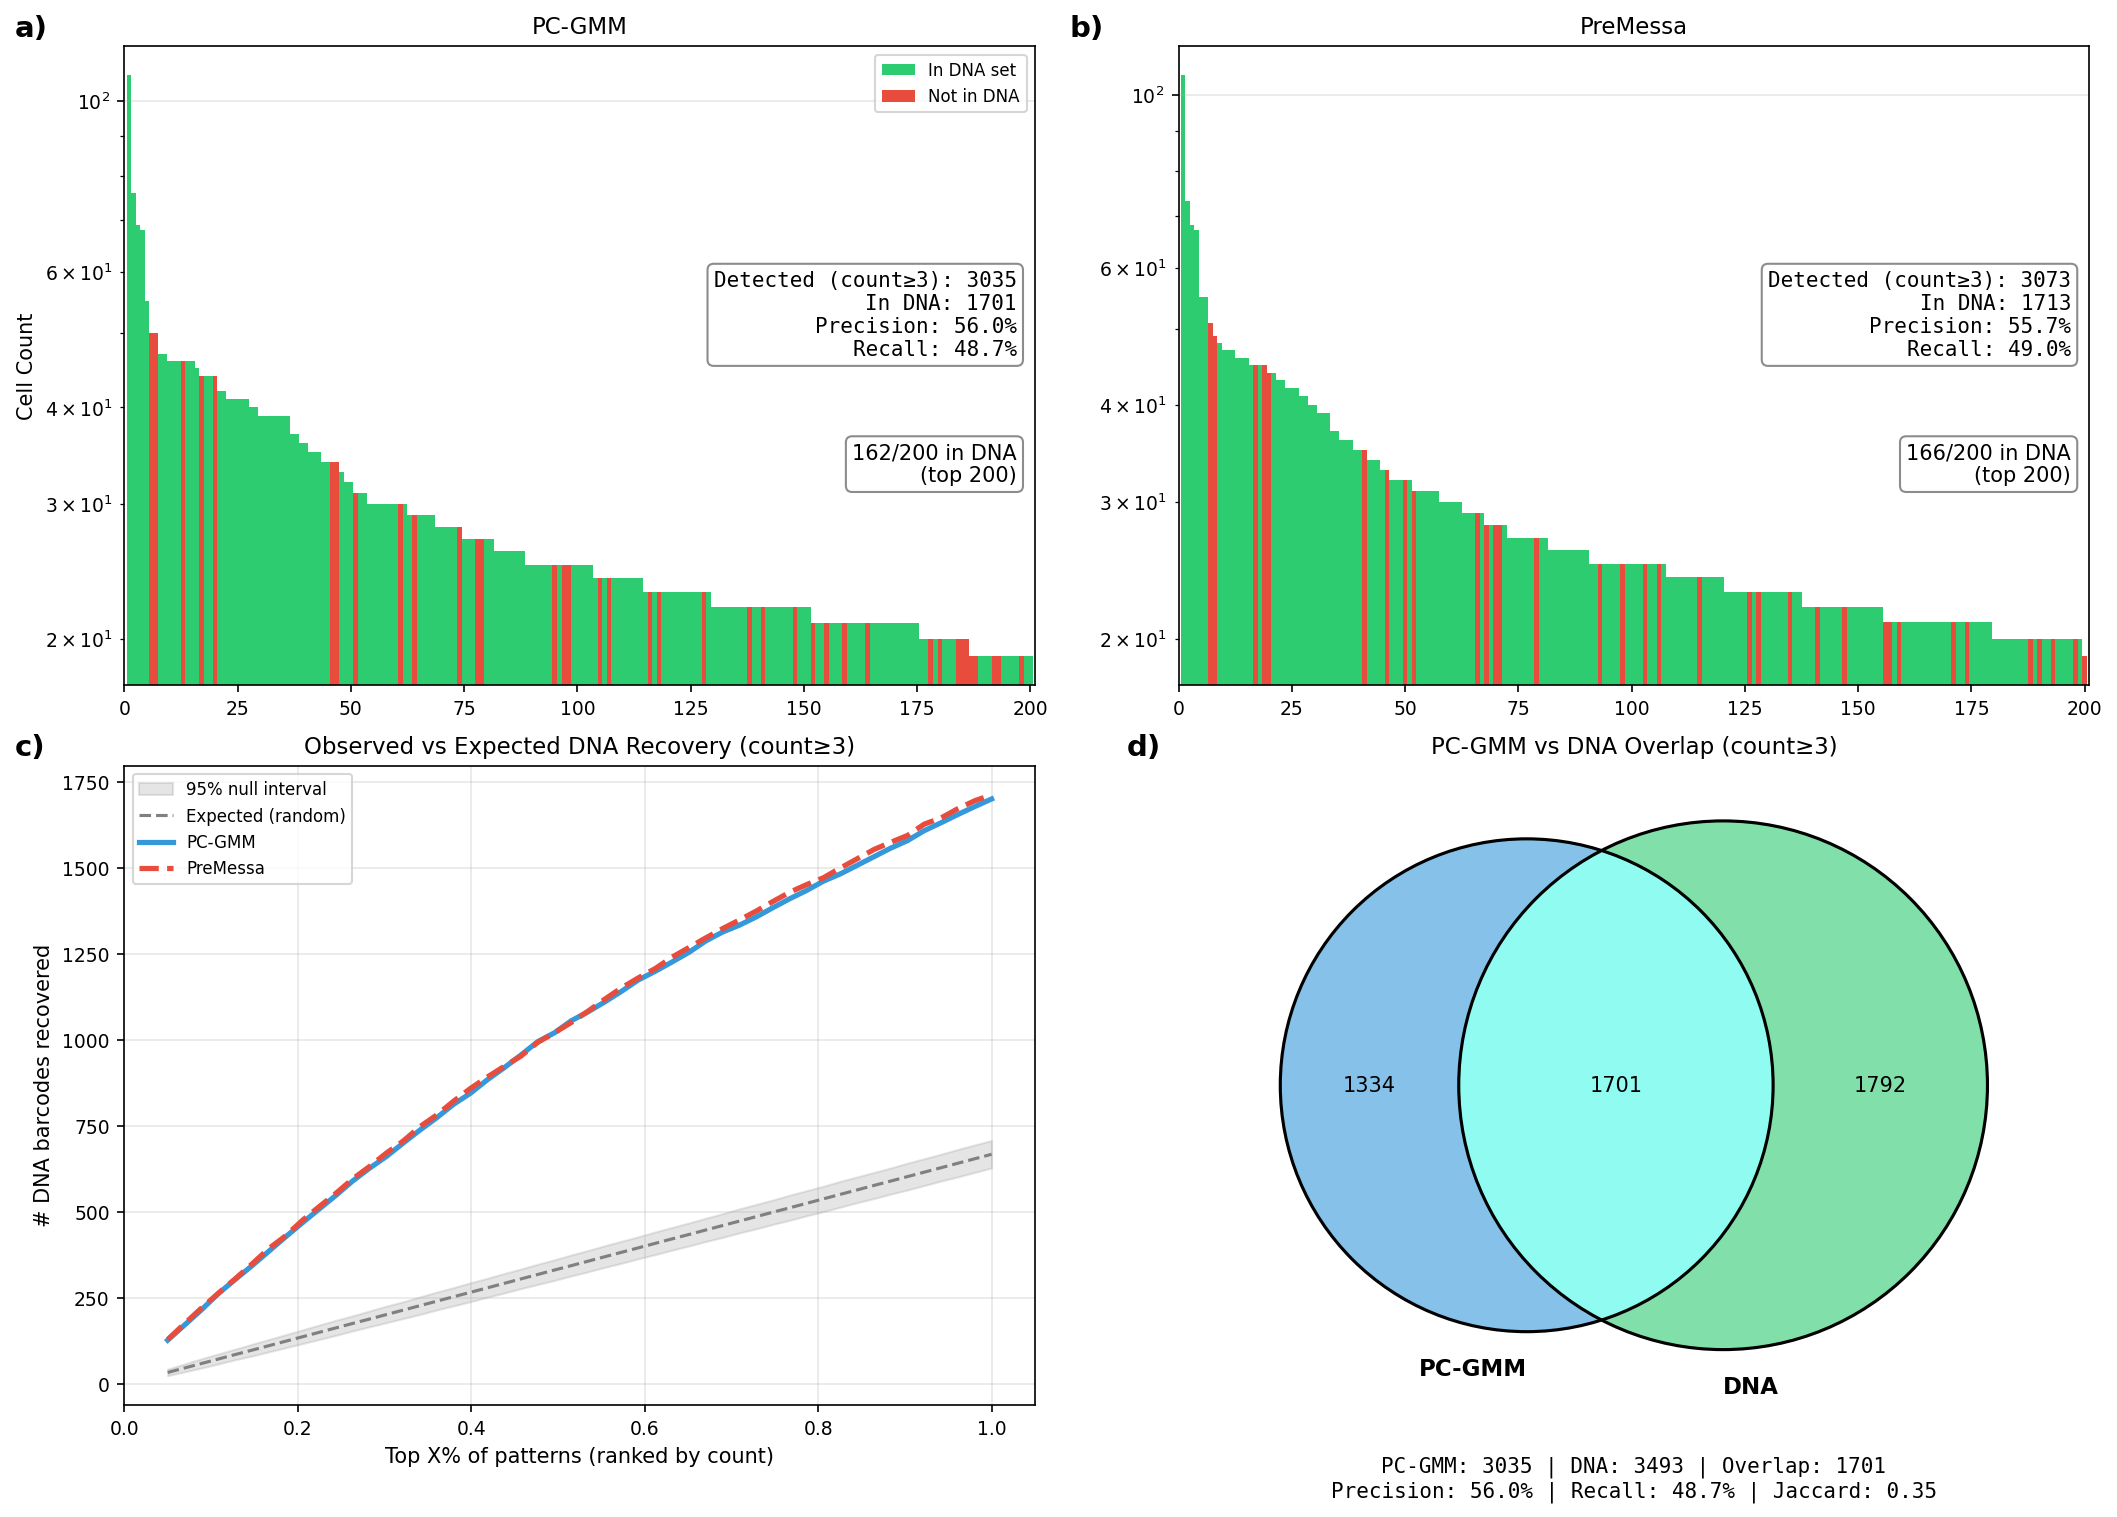

In [6]:
def load_key_file(key_path, mapping_path):
    """Load Key_15K.csv and create BC_ID <-> pattern mapping."""
    mapping_df = pd.read_csv(mapping_path)
    mapping_channels = {}
    for _, row in mapping_df.iterrows():
        bc_seq = int(row['bc_sequence'])
        parts = row['channel_name'].split('_')[0]
        channel = ''.join(c for c in parts if c.isalpha()) + ''.join(c for c in parts if c.isdigit()) + 'Di'
        mapping_channels[bc_seq] = channel
    library_order = [mapping_channels[i] for i in range(1, 19)]
    
    key_df = pd.read_csv(key_path)
    bc_id_col = key_df.columns[0]
    key_channels = list(key_df.columns[1:])
    key_to_lib_order = [key_channels.index(ch) for ch in library_order]
    
    id_to_pattern, pattern_to_id = {}, {}
    for _, row in key_df.iterrows():
        bc_id = int(row[bc_id_col])
        key_bits = [str(int(row[key_channels[i]])) for i in range(18)]
        pattern = ''.join(key_bits[key_to_lib_order[i]] for i in range(18))
        id_to_pattern[bc_id] = pattern
        pattern_to_id[pattern] = bc_id
    return id_to_pattern, pattern_to_id

def load_ngs_data(ngs_path):
    """Load NGS barcode counts."""
    df = pd.read_csv(ngs_path)
    dna_counts = {}
    for _, row in df.iterrows():
        if row['presence'] != 1:
            continue
        bc_id = row.iloc[10] 
        if pd.isna(bc_id):
            continue
        bc_id = int(bc_id)
        count = int(row['countx presence'])
        dna_counts[bc_id] = dna_counts.get(bc_id, 0) + count
    return dna_counts

id_to_pattern, pattern_to_id = load_key_file(f'{DATA_DIR}/Key_15K.csv', f'{DATA_DIR}/barcode_channel_mapping_18ch.csv')
dna_counts = load_ngs_data(f'{DATA_DIR}/NGS_RM1R1_15K_bcM_240404.csv')
dna_bc_ids = set(dna_counts.keys())

adata_15k = xd.io.read_data(f'{DATA_DIR}/15k_test.fcs')
adata_15k = xd.io.map_channels(adata_15k, f'{DATA_DIR}/barcode_channel_mapping_18ch.csv')
adata_15k = xd.preprocessing.transform(adata_15k, "log", verbose=False)
adata_15k = xd.preprocessing.filter_cells_intensity(adata_15k, layer='log', method='ellipsoidal',
                                                     percentile=90.0, filter_or_flag='filter')
adata_15k = xd.debarcode.debarcode(adata_15k, method='pc_gmm', layer='log', verbose=False)
adata_15k = xd.debarcode.debarcode(adata_15k, method='premessa', layer='log', verbose=False)

MIN_COUNT = 3

def plot_rank_count_dna(ax, assignments, pattern_to_id, dna_bc_ids, top_n=200, 
                        min_count=3, show_legend=True, panel_label=None):
    """Rank-count with DNA membership highlighting."""
    counts = {p: c for p, c in Counter(assignments).items() if c >= min_count}
    sorted_patterns = sorted(counts.items(), key=lambda x: -x[1])[:top_n]
    ranks = np.arange(1, len(sorted_patterns) + 1)
    abundances = [c for _, c in sorted_patterns]
    
    bar_colors = [DNA_COLOR if (p in pattern_to_id and pattern_to_id[p] in dna_bc_ids) else NON_DNA_COLOR 
                  for p, _ in sorted_patterns]
    n_in_dna = sum(1 for c in bar_colors if c == DNA_COLOR)
    
    ax.bar(ranks, abundances, color=bar_colors, width=1.0, edgecolor='none')
    ax.set_yscale('log')
    ax.set_xlabel('Rank')
    ax.set_ylabel('Cell Count')
    ax.set_xlim(0, min(top_n, len(sorted_patterns)) + 1)
    ax.grid(True, alpha=0.3, axis='y')
    
    if show_legend:
        ax.legend(handles=[Patch(facecolor=DNA_COLOR, label='In DNA set'),
                          Patch(facecolor=NON_DNA_COLOR, label='Not in DNA')], loc='upper right', fontsize=8)
    
    # Stats
    all_patterns = set(counts.keys())
    cytof_bc_ids = {pattern_to_id[p] for p in all_patterns if p in pattern_to_id}
    intersection = cytof_bc_ids & dna_bc_ids
    n_det, n_dna = len(cytof_bc_ids), len(intersection)
    prec, rec = (n_dna/n_det if n_det else 0), (n_dna/len(dna_bc_ids) if dna_bc_ids else 0)
    
    ax.text(0.98, 0.65, f"Detected (count≥{min_count}): {n_det}\nIn DNA: {n_dna}\nPrecision: {prec:.1%}\nRecall: {rec:.1%}",
            transform=ax.transAxes, fontsize=10, va='top', ha='right', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='grey'))
    ax.text(0.98, 0.38, f'{n_in_dna}/{len(sorted_patterns)} in DNA\n(top {len(sorted_patterns)})',
            transform=ax.transAxes, fontsize=10, va='top', ha='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='grey'))
    
    if panel_label:
        add_panel_label(ax, panel_label)

def plot_dna_recovery_curve(ax, methods_data, dna_size, universe_size, min_count=3, panel_label=None):
    """Observed vs expected DNA recovery curve."""
    coverage_points = np.linspace(0.05, 1.0, 50)
    
    def get_patterns_by_count(assignments, coverage, min_count):
        pattern_counts = {p: c for p, c in Counter(assignments).items() if c >= min_count}
        if not pattern_counts:
            return set()
        sorted_p = sorted(pattern_counts.keys(), key=lambda p: -pattern_counts[p])
        return set(sorted_p[:max(1, int(len(sorted_p) * coverage))])
    
    # Null band from first method
    first = list(methods_data.values())[0]
    expected_line, ci_low, ci_high = [], [], []
    for cov in coverage_points:
        patterns = get_patterns_by_count(first['assignments'], cov, min_count)
        bc_ids = {first['pattern_to_id'][p] for p in patterns if p in first['pattern_to_id']}
        n_det = len(bc_ids)
        if n_det > 0:
            rv = hypergeom(universe_size, dna_size, n_det)
            expected_line.append(rv.mean())
            ci_low.append(rv.ppf(0.025))
            ci_high.append(rv.ppf(0.975))
        else:
            expected_line.append(0)
            ci_low.append(0)
            ci_high.append(0)
    
    ax.fill_between(coverage_points, ci_low, ci_high, color='grey', alpha=0.2, label='95% null interval')
    ax.plot(coverage_points, expected_line, color='grey', linestyle='--', linewidth=1.5, label='Expected (random)')
    
    for name, v in methods_data.items():
        overlaps = []
        for cov in coverage_points:
            patterns = get_patterns_by_count(v['assignments'], cov, min_count)
            bc_ids = {v['pattern_to_id'][p] for p in patterns if p in v['pattern_to_id']}
            overlaps.append(len(bc_ids & v['dna_bc_ids']))
        ax.plot(coverage_points, overlaps, color=v['color'], linestyle=v['linestyle'], linewidth=2.5, label=name)
    
    ax.set_xlabel('Top X% of patterns (ranked by count)')
    ax.set_ylabel('# DNA barcodes recovered')
    ax.set_title(f'Observed vs Expected DNA Recovery (count≥{min_count})')
    ax.set_xlim(0, 1.05)
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)
    if panel_label:
        add_panel_label(ax, panel_label)

def plot_venn_pcgmm_dna(ax, adata, pattern_to_id, dna_bc_ids, min_count=3, panel_label=None):
    """2-way Venn diagram PC-GMM vs DNA."""
    try:
        from matplotlib_venn import venn2, venn2_circles
    except ImportError:
        ax.text(0.5, 0.5, 'matplotlib-venn not installed', ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()
        return
    
    pcgmm_counts = Counter(adata.obs['pc_gmm_assignment'].values)
    pcgmm_patterns = {p for p, c in pcgmm_counts.items() if c >= min_count}
    pcgmm_bc_ids = {pattern_to_id[p] for p in pcgmm_patterns if p in pattern_to_id}
    
    v = venn2([pcgmm_bc_ids, dna_bc_ids], set_labels=('PC-GMM', 'DNA'),
              set_colors=('#3498db', '#2ecc71'), alpha=0.6, ax=ax)
    venn2_circles([pcgmm_bc_ids, dna_bc_ids], linewidth=1.5, ax=ax)
    
    for text in v.set_labels:
        if text:
            text.set_fontsize(11)
            text.set_fontweight('bold')
    for text in v.subset_labels:
        if text:
            text.set_fontsize(10)
    
    ax.set_title(f'PC-GMM vs DNA Overlap (count≥{min_count})')
    
    overlap = len(pcgmm_bc_ids & dna_bc_ids)
    union = len(pcgmm_bc_ids | dna_bc_ids)
    jaccard = overlap / union if union else 0
    prec = overlap / len(pcgmm_bc_ids) if pcgmm_bc_ids else 0
    rec = overlap / len(dna_bc_ids) if dna_bc_ids else 0
    
    ax.text(0.5, -0.08, f'PC-GMM: {len(pcgmm_bc_ids)} | DNA: {len(dna_bc_ids)} | Overlap: {overlap}\n'
            f'Precision: {prec:.1%} | Recall: {rec:.1%} | Jaccard: {jaccard:.2f}',
            transform=ax.transAxes, ha='center', va='top', fontsize=10, fontfamily='monospace')
    
    if panel_label:
        add_panel_label(ax, panel_label)

fig2 = plt.figure(figsize=(14, 10), constrained_layout=True)

ax2a = fig2.add_subplot(2, 2, 1)
plot_rank_count_dna(ax2a, adata_15k.obs['pc_gmm_assignment'].values, pattern_to_id, dna_bc_ids,
                    min_count=MIN_COUNT, panel_label='a')
ax2a.set_title('PC-GMM')
ax2a.set_xlabel('')

ax2b = fig2.add_subplot(2, 2, 2)
plot_rank_count_dna(ax2b, adata_15k.obs['premessa_assignment'].values, pattern_to_id, dna_bc_ids,
                    min_count=MIN_COUNT, show_legend=False, panel_label='b')
ax2b.set_title('PreMessa')
ax2b.set_xlabel('')
ax2b.set_ylabel('')

methods_data = {
    'PC-GMM': {'assignments': adata_15k.obs['pc_gmm_assignment'].values, 'pattern_to_id': pattern_to_id,
               'dna_bc_ids': dna_bc_ids, 'color': '#3498db', 'linestyle': '-'},
    'PreMessa': {'assignments': adata_15k.obs['premessa_assignment'].values, 'pattern_to_id': pattern_to_id,
                 'dna_bc_ids': dna_bc_ids, 'color': '#e74c3c', 'linestyle': '--'},
}

ax2c = fig2.add_subplot(2, 2, 3)
plot_dna_recovery_curve(ax2c, methods_data, len(dna_bc_ids), UNIVERSE_18CH, min_count=MIN_COUNT, panel_label='c')

ax2d = fig2.add_subplot(2, 2, 4)
plot_venn_pcgmm_dna(ax2d, adata_15k, pattern_to_id, dna_bc_ids, min_count=MIN_COUNT, panel_label='d')

save_figure(fig2, f'{OUTPUT_DIR}/main/fig2_15K_dna_concordance')
plt.show()

# Supplementary

## Method comparison (FigS1)

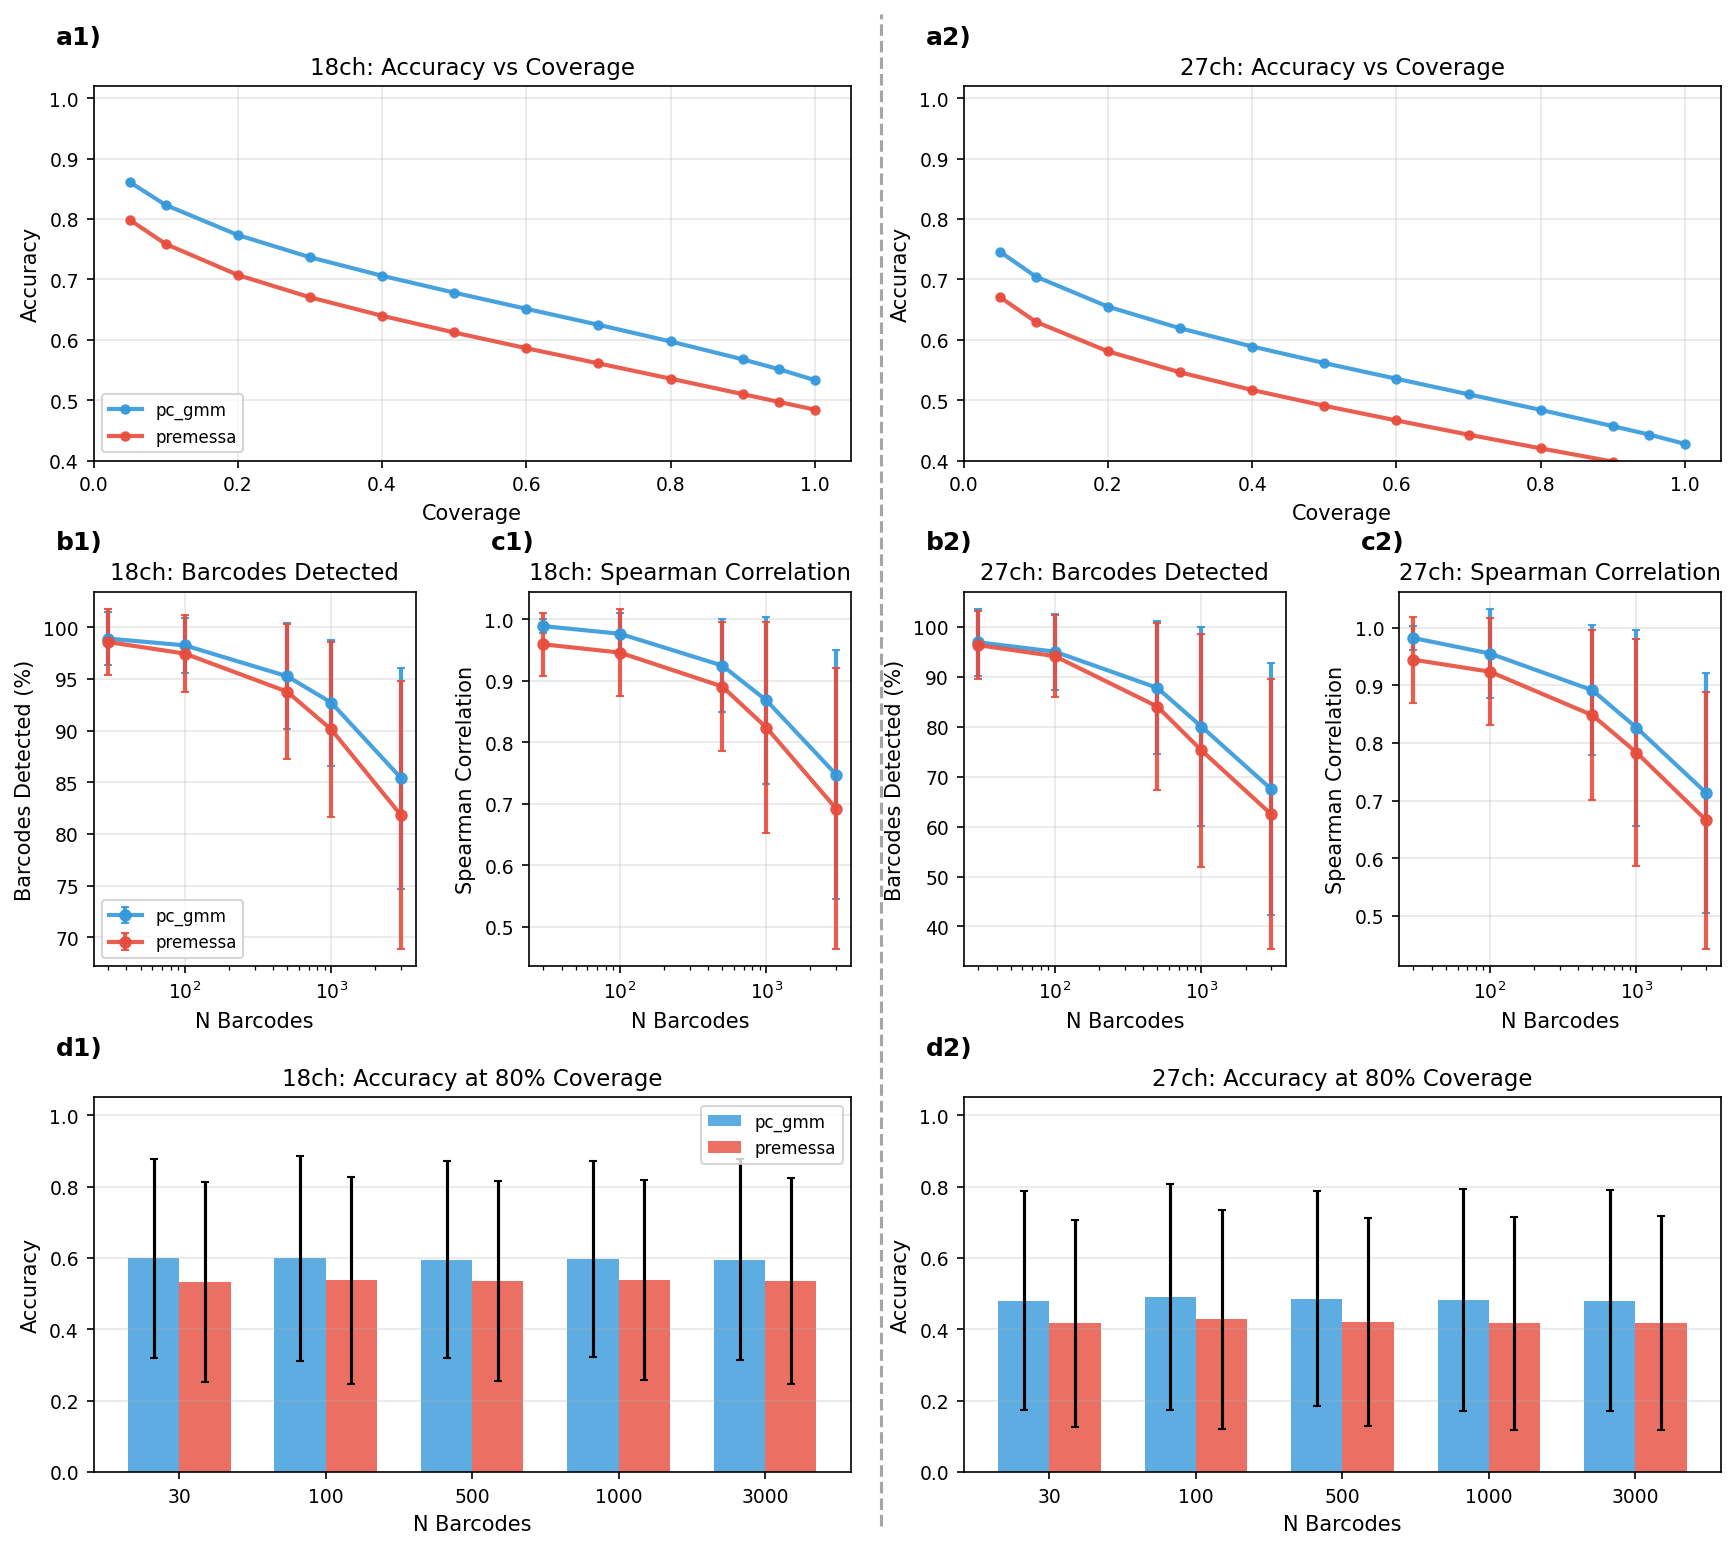

In [7]:
df = pd.read_csv(f'{DATA_DIR}/simulation_results/benchmark_summary.csv')
df_curves = pd.read_csv(f'{DATA_DIR}/simulation_results/benchmark_curves.csv')

df = df[df['n_barcodes'] >= 30]
df_curves = df_curves[df_curves['n_barcodes'] >= 30]

methods = ['pc_gmm', 'premessa']
FIXED_COVERAGE = 0.8

def add_label(ax, label):
    ax.annotate(label, xy=(0, 1), xycoords='axes fraction',
                xytext=(-18, 18), textcoords='offset points',
                fontsize=12, fontweight='bold', va='bottom', ha='left')

def compute_mean_roc_curve(curves_sub, stage='baseline'):
    coverage_col = f'{stage}_coverage'
    accuracy_col = f'{stage}_accuracy'
    grouped = curves_sub.groupby('selection_frac').agg({
        coverage_col: 'mean',
        accuracy_col: ['mean', 'std']
    }).reset_index()
    grouped.columns = ['selection_frac', 'coverage_mean', 'accuracy_mean', 'accuracy_std']
    return grouped['coverage_mean'].tolist(), grouped['accuracy_mean'].tolist(), grouped['accuracy_std'].fillna(0).tolist()

def get_accuracy_at_fixed_coverage(curves_sub, fixed_cov, stage='baseline'):
    coverage_col = f'{stage}_coverage'
    accuracy_col = f'{stage}_accuracy'
    grouped = curves_sub.groupby('selection_frac').agg({
        coverage_col: 'mean',
        accuracy_col: ['mean', 'std']
    }).reset_index()
    grouped.columns = ['selection_frac', 'coverage_mean', 'accuracy_mean', 'accuracy_std']
    grouped = grouped.sort_values('coverage_mean')
    coverages = grouped['coverage_mean'].values
    accuracies = grouped['accuracy_mean'].values
    accuracies_std = grouped['accuracy_std'].fillna(0).values
    if len(coverages) == 0:
        return np.nan, np.nan
    if fixed_cov > coverages.max():
        return np.nan, np.nan
    if fixed_cov < coverages.min():
        return accuracies[0], accuracies_std[0]
    acc_mean = np.interp(fixed_cov, coverages, accuracies)
    acc_std = np.interp(fixed_cov, coverages, accuracies_std)
    return acc_mean, acc_std

fig = plt.figure(figsize=(14, 12))
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.35, wspace=0.35, height_ratios=[1, 1, 1])
channels = [(18, '18ch'), (27, '27ch')]

# Row 1: ROC Coverage-Accuracy Curves
for col_offset, (ch, ch_label) in enumerate(channels):
    ax = fig.add_subplot(gs[0, col_offset * 2: col_offset * 2 + 2])
    add_label(ax, f'a{col_offset + 1})')
    for method in methods:
        curves_sub = df_curves[(df_curves['n_channels'] == ch) & (df_curves['debarcode_method'] == method)]
        if len(curves_sub) == 0:
            continue
        covs_base, accs_base, _ = compute_mean_roc_curve(curves_sub, 'baseline')
        if covs_base:
            ax.plot(covs_base, accs_base, 'o-', color=METHOD_COLORS[method], 
                    markersize=4, linewidth=2, alpha=0.9, label=method)
    ax.set_xlabel('Coverage')
    ax.set_ylabel('Accuracy')
    if col_offset == 0:
        ax.legend(loc='lower left', fontsize=8)
    ax.set_title(f'{ch_label}: Accuracy vs Coverage')
    ax.set_xlim(0, 1.05)
    ax.set_ylim(0.4, 1.02)
    ax.grid(True, alpha=0.3)

line = plt.Line2D([0.5, 0.5], [0.08, 0.92], transform=fig.transFigure,
                  color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
fig.add_artist(line)

# Row 2: Barcodes Detected and Spearman
for col_offset, (ch, ch_label) in enumerate(channels):
    ax = fig.add_subplot(gs[1, col_offset * 2])
    add_label(ax, f'b{col_offset + 1})')
    for method in methods:
        sub = df[(df['n_channels'] == ch) & (df['debarcode_method'] == method)]
        if len(sub) > 0:
            grouped = sub.groupby('n_barcodes')['baseline_pct_barcodes_detected'].agg(['mean', 'std'])
            ax.errorbar(grouped.index, grouped['mean'].values * 100, 
                        yerr=grouped['std'].fillna(0).values * 100,
                        fmt='o-', color=METHOD_COLORS[method], alpha=0.9,
                        markersize=5, linewidth=2, capsize=2, capthick=1, label=method)
    ax.set_xlabel('N Barcodes')
    ax.set_ylabel('Barcodes Detected (%)')
    if col_offset == 0:
        ax.legend(loc='lower left', fontsize=8)
    ax.set_title(f'{ch_label}: Barcodes Detected')
    ax.set_xscale('log')
    ax.grid(True, alpha=0.3)
    
    # Spearman Correlation
    ax = fig.add_subplot(gs[1, col_offset * 2 + 1])
    add_label(ax, f'c{col_offset + 1})')
    for method in methods:
        sub = df[(df['n_channels'] == ch) & (df['debarcode_method'] == method)]
        if len(sub) > 0:
            grouped = sub.groupby('n_barcodes')['baseline_spearman'].agg(['mean', 'std'])
            ax.errorbar(grouped.index, grouped['mean'].values,
                        yerr=grouped['std'].fillna(0).values,
                        fmt='o-', color=METHOD_COLORS[method], alpha=0.9,
                        markersize=5, linewidth=2, capsize=2, capthick=1, label=method)
    ax.set_xlabel('N Barcodes')
    ax.set_ylabel('Spearman Correlation')
    ax.set_title(f'{ch_label}: Spearman Correlation')
    ax.set_xscale('log')
    ax.grid(True, alpha=0.3)

# Row 3: Accuracy at Fixed Coverage Bar Plots
for col_offset, (ch, ch_label) in enumerate(channels):
    ax = fig.add_subplot(gs[2, col_offset * 2: col_offset * 2 + 2])
    add_label(ax, f'd{col_offset + 1})')
    barcodes = sorted(df[df['n_channels'] == ch]['n_barcodes'].unique())
    x = np.arange(len(barcodes))
    width = 0.35
    
    for i, method in enumerate(methods):
        acc_means = []
        acc_stds = []
        for bc in barcodes:
            curves_sub = df_curves[(df_curves['n_channels'] == ch) & 
                                   (df_curves['debarcode_method'] == method) &
                                   (df_curves['n_barcodes'] == bc)]
            if len(curves_sub) > 0:
                acc_mean, acc_std = get_accuracy_at_fixed_coverage(curves_sub, FIXED_COVERAGE, 'baseline')
                acc_means.append(acc_mean)
                acc_stds.append(acc_std)
            else:
                acc_means.append(np.nan)
                acc_stds.append(np.nan)
        
        acc_means = np.array(acc_means)
        acc_stds = np.array(acc_stds)
        valid = ~np.isnan(acc_means)
        if valid.any():
            ax.bar(x[valid] + i*width - width/2, acc_means[valid], width,
                   color=METHOD_COLORS[method], alpha=0.8, label=method,
                   yerr=acc_stds[valid], capsize=2, error_kw={'capthick': 1})
    
    ax.set_xticks(x)
    ax.set_xticklabels(barcodes)
    ax.set_xlabel('N Barcodes')
    ax.set_ylabel('Accuracy')
    if col_offset == 0:
        ax.legend(loc='upper right', fontsize=8)
    ax.set_title(f'{ch_label}: Accuracy at {int(FIXED_COVERAGE*100)}% Coverage')
    ax.set_ylim(0, 1.05)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout(rect=[0, 0, 1, 0.96])
save_figure(fig, f'{OUTPUT_DIR}/supplementary/figS1_method_comparison_baseline')
plt.show()

## Hamming performance (FigS2)

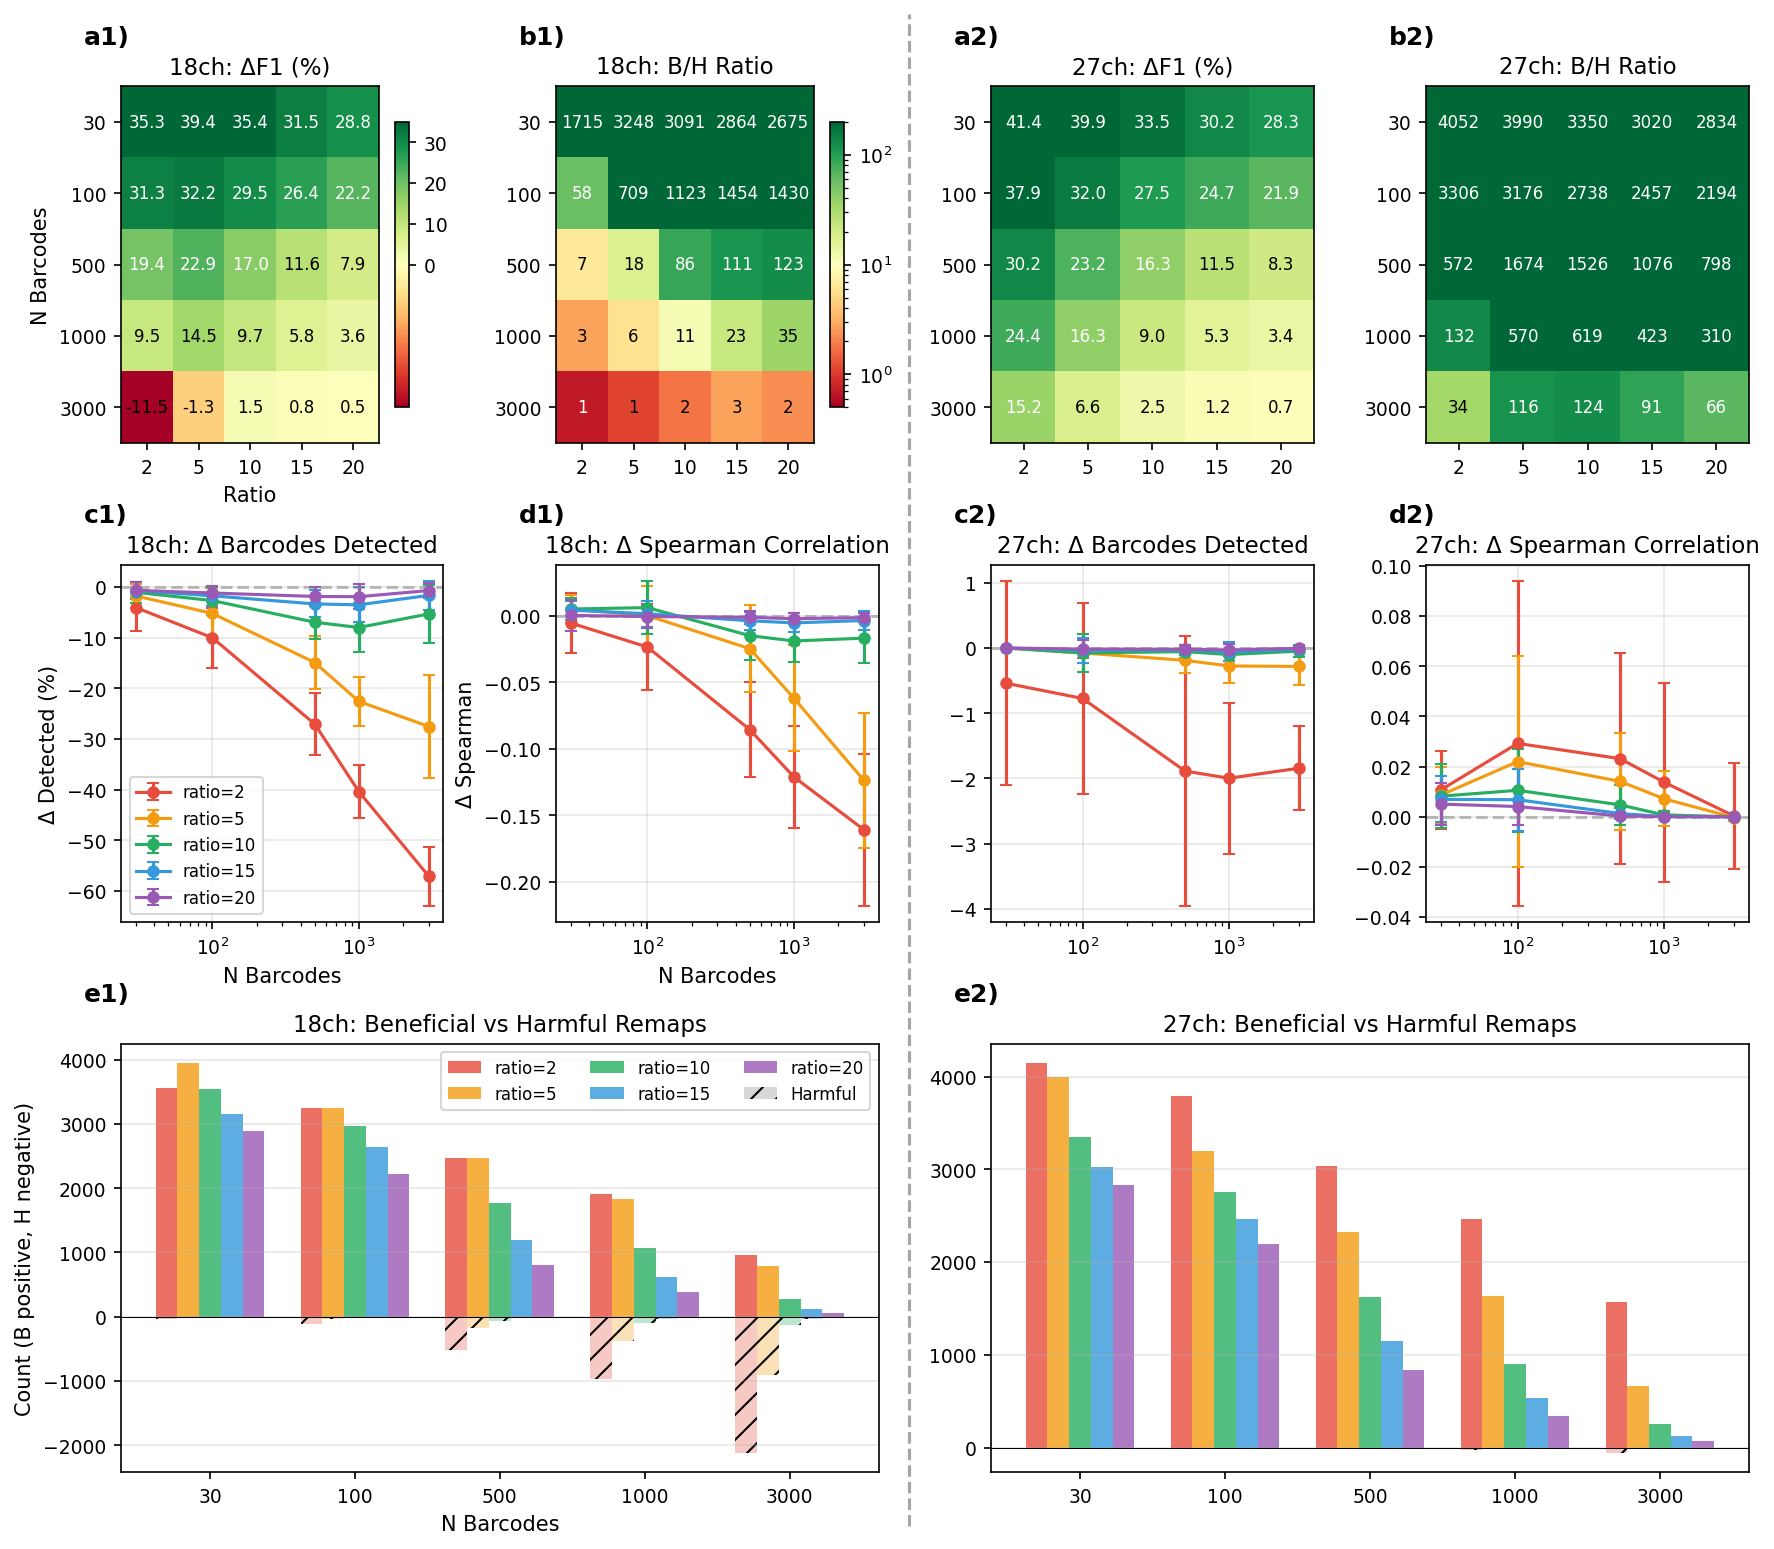

In [8]:
df = pd.read_csv(f'{DATA_DIR}/simulation_results/benchmark_summary.csv')
df = df[(df['n_barcodes'] > 10) & 
        (df['debarcode_method'] == 'pc_gmm') & 
        (df['hamming_method'] == 'msg')]

def add_label(ax, label):
    ax.annotate(label, xy=(0, 1), xycoords='axes fraction',
                xytext=(-18, 18), textcoords='offset points',
                fontsize=12, fontweight='bold', va='bottom', ha='left')

fig = plt.figure(figsize=(14, 12))
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.32, wspace=0.35, height_ratios=[1, 1, 1.2])
channels = [(18, '18ch'), (27, '27ch')]

# Row 1: Heatmaps
for col_offset, (ch, ch_label) in enumerate(channels):
    sub = df[df['n_channels'] == ch]
    barcodes = sorted(sub['n_barcodes'].unique())
    ratios = sorted(sub['ratio'].unique())
    label_suffix = col_offset + 1
    
    # ΔF1 heatmap
    ax = fig.add_subplot(gs[0, col_offset * 2])
    add_label(ax, f'a{label_suffix})')
    pivot = sub.groupby(['n_barcodes', 'ratio'])['f1_delta'].mean().unstack()
    pivot = pivot.reindex(index=barcodes, columns=ratios)
    im = ax.imshow(pivot.values * 100, cmap='RdYlGn', 
                   norm=TwoSlopeNorm(vmin=-5, vcenter=0, vmax=35), aspect='auto')
    ax.set_xticks(range(len(ratios)))
    ax.set_xticklabels(ratios)
    ax.set_yticks(range(len(barcodes)))
    ax.set_yticklabels(barcodes)
    if col_offset == 0:
        ax.set_xlabel('Ratio')
        ax.set_ylabel('N Barcodes')
    ax.set_title(f'{ch_label}: ΔF1 (%)')
    for i in range(len(barcodes)):
        for j in range(len(ratios)):
            val = pivot.values[i, j] * 100
            color = 'white' if abs(val) > 15 else 'black'
            ax.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=8, color=color)
    if col_offset == 0:
        plt.colorbar(im, ax=ax, shrink=0.8)
    
    # B/H Ratio heatmap
    ax = fig.add_subplot(gs[0, col_offset * 2 + 1])
    add_label(ax, f'b{label_suffix})')
    pivot_bh = sub.groupby(['n_barcodes', 'ratio'])['bh_ratio'].mean().unstack()
    pivot_bh = pivot_bh.reindex(index=barcodes, columns=ratios)
    im = ax.imshow(pivot_bh.values, cmap='RdYlGn', norm=LogNorm(vmin=0.5, vmax=200), aspect='auto')
    ax.set_xticks(range(len(ratios)))
    ax.set_xticklabels(ratios)
    ax.set_yticks(range(len(barcodes)))
    ax.set_yticklabels(barcodes)
    ax.set_title(f'{ch_label}: B/H Ratio')
    for i in range(len(barcodes)):
        for j in range(len(ratios)):
            val = pivot_bh.values[i, j]
            color = 'white' if val > 50 or val < 1 else 'black'
            ax.text(j, i, f'{val:.0f}', ha='center', va='center', fontsize=8, color=color)
    if col_offset == 0:
        plt.colorbar(im, ax=ax, shrink=0.8)

line = plt.Line2D([0.5, 0.5], [0.08, 0.92], transform=fig.transFigure,
                  color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
fig.add_artist(line)

# Row 2: Delta Detected and Spearman
for col_offset, (ch, ch_label) in enumerate(channels):
    sub = df[df['n_channels'] == ch]
    barcodes = sorted(sub['n_barcodes'].unique())
    label_suffix = col_offset + 1
    
    # Delta barcodes detected
    ax = fig.add_subplot(gs[1, col_offset * 2])
    add_label(ax, f'c{label_suffix})')
    for ratio in sorted(sub['ratio'].unique()):
        subset = sub[sub['ratio'] == ratio]
        means = subset.groupby('n_barcodes')['pct_barcodes_detected_delta'].mean()
        stds = subset.groupby('n_barcodes')['pct_barcodes_detected_delta'].std()
        ax.errorbar(means.index, means.values * 100, yerr=stds.values * 100,
                    marker='o', label=f'ratio={ratio}', color=RATIO_COLORS[ratio],
                    capsize=3, markersize=5)
    if col_offset == 0:
        ax.set_xlabel('N Barcodes')
        ax.set_ylabel('Δ Detected (%)')
    ax.set_title(f'{ch_label}: Δ Barcodes Detected')
    if col_offset == 0:
        ax.legend(loc='lower left', fontsize=8)
    ax.set_xscale('log')
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.3)
    
    # Spearman change
    ax = fig.add_subplot(gs[1, col_offset * 2 + 1])
    add_label(ax, f'd{label_suffix})')
    for ratio in sorted(sub['ratio'].unique()):
        subset = sub[sub['ratio'] == ratio]
        means = subset.groupby('n_barcodes')['spearman_delta'].mean()
        stds = subset.groupby('n_barcodes')['spearman_delta'].std()
        ax.errorbar(means.index, means.values, yerr=stds.values,
                    marker='o', color=RATIO_COLORS[ratio], capsize=3, markersize=5)
    if col_offset == 0:
        ax.set_xlabel('N Barcodes')
        ax.set_ylabel('Δ Spearman')
    ax.set_title(f'{ch_label}: Δ Spearman Correlation')
    ax.set_xscale('log')
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.3)

# Row 3: Beneficial vs Harmful
for col_offset, (ch, ch_label) in enumerate(channels):
    ax = fig.add_subplot(gs[2, col_offset * 2: col_offset * 2 + 2])
    label_suffix = col_offset + 1
    add_label(ax, f'e{label_suffix})')
    
    sub = df[df['n_channels'] == ch]
    barcodes = sorted(sub['n_barcodes'].unique())
    x = np.arange(len(barcodes))
    width = 0.15
    
    for i, ratio in enumerate(sorted(sub['ratio'].unique())):
        subset = sub[sub['ratio'] == ratio]
        beneficial = subset.groupby('n_barcodes')['beneficial'].mean().values
        harmful = subset.groupby('n_barcodes')['harmful'].mean().values
        ax.bar(x + i*width - 2*width, beneficial, width, color=RATIO_COLORS[ratio], alpha=0.8)
        ax.bar(x + i*width - 2*width, -harmful, width, color=RATIO_COLORS[ratio], alpha=0.3, hatch='//')
    
    ax.set_xticks(x)
    ax.set_xticklabels(barcodes)
    if col_offset == 0:
        ax.set_xlabel('N Barcodes')
        ax.set_ylabel('Count (B positive, H negative)')
    ax.set_title(f'{ch_label}: Beneficial vs Harmful Remaps')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.grid(True, alpha=0.3, axis='y')
    
    if col_offset == 0:
        legend_elements = [Patch(facecolor=RATIO_COLORS[r], alpha=0.8, label=f'ratio={r}')
                          for r in sorted(sub['ratio'].unique())]
        legend_elements.append(Patch(facecolor='gray', alpha=0.3, hatch='//', label='Harmful'))
        ax.legend(handles=legend_elements, loc='upper right', fontsize=8, ncol=3)

plt.tight_layout(rect=[0, 0, 1, 0.96])
save_figure(fig, f'{OUTPUT_DIR}/supplementary/figS2_hamming_msg_performance')
plt.show()

## Unimodal regime (FigS3)

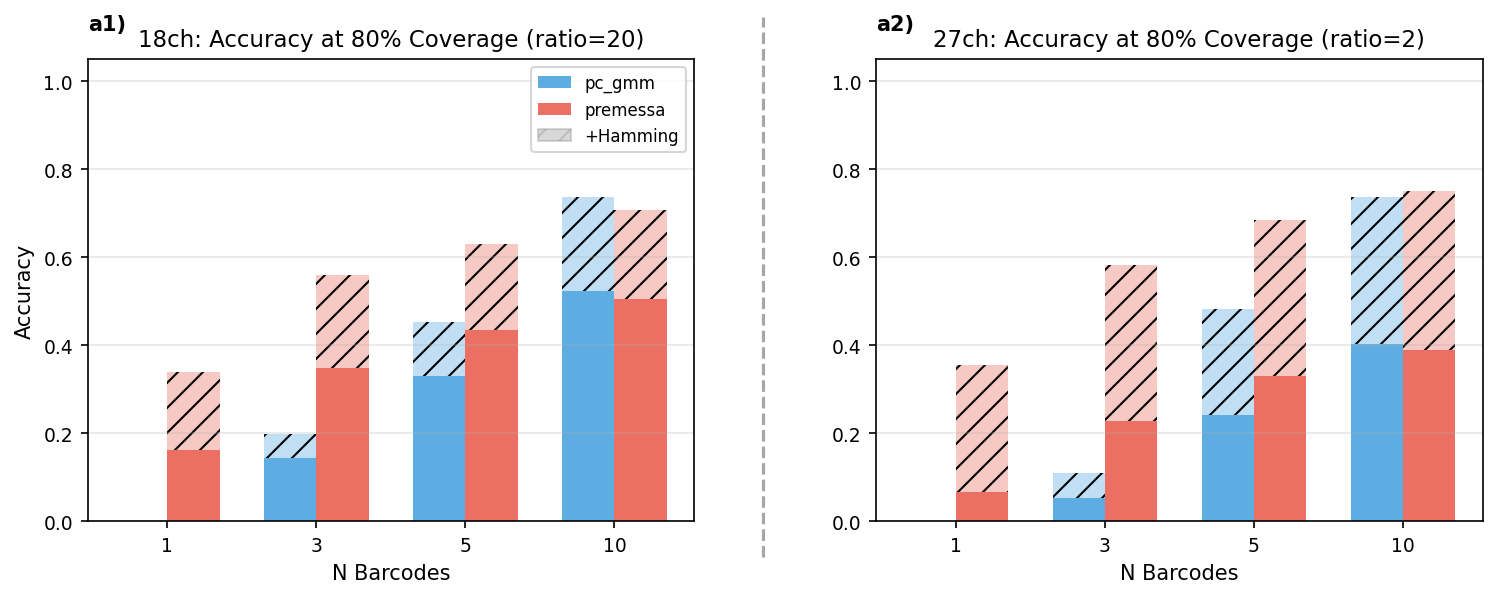

In [9]:
df = pd.read_csv(f'{DATA_DIR}/simulation_results/benchmark_summary.csv')
df_curves = pd.read_csv(f'{DATA_DIR}/simulation_results/benchmark_curves.csv')
df = df[df['n_barcodes'] <= 10]
df_curves = df_curves[df_curves['n_barcodes'] <= 10]

methods = ['pc_gmm', 'premessa']
hamming_settings = {18: {'ratio': 20}, 27: {'ratio': 2}}
FIXED_COVERAGE = 0.8

def add_label(ax, label):
    ax.annotate(label, xy=(0, 1), xycoords='axes fraction',
                xytext=(0, 12), textcoords='offset points',
                fontsize=10, fontweight='bold', va='bottom', ha='left')

def get_accuracy_at_fixed_coverage(curves_sub, fixed_cov, stage='baseline'):
    coverage_col = f'{stage}_coverage'
    accuracy_col = f'{stage}_accuracy'
    grouped = curves_sub.groupby('selection_frac').agg({
        coverage_col: 'mean',
        accuracy_col: ['mean', 'std']
    }).reset_index()
    grouped.columns = ['selection_frac', 'coverage_mean', 'accuracy_mean', 'accuracy_std']
    grouped = grouped.sort_values('coverage_mean')
    coverages = grouped['coverage_mean'].values
    accuracies = grouped['accuracy_mean'].values
    accuracies_std = grouped['accuracy_std'].fillna(0).values
    if len(coverages) == 0:
        return np.nan, np.nan
    if fixed_cov > coverages.max():
        return np.nan, np.nan
    if fixed_cov < coverages.min():
        return accuracies[0], accuracies_std[0]
    acc_mean = np.interp(fixed_cov, coverages, accuracies)
    acc_std = np.interp(fixed_cov, coverages, accuracies_std)
    return acc_mean, acc_std

fig = plt.figure(figsize=(12, 4))
gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.30)
channels = [(18, '18ch'), (27, '27ch')]

for col_offset, (ch, ch_label) in enumerate(channels):
    ax = fig.add_subplot(gs[0, col_offset])
    add_label(ax, f'a{col_offset + 1})')
    
    ratio = hamming_settings[ch]['ratio']
    barcodes = sorted(df[df['n_channels'] == ch]['n_barcodes'].unique())
    x = np.arange(len(barcodes))
    width = 0.35
    
    for i, method in enumerate(methods):
        acc_pre_means = []
        acc_pre_stds = []
        acc_post_means = []
        acc_post_stds = []
        
        for bc in barcodes:
            curves_sub = df_curves[(df_curves['n_channels'] == ch) & 
                                   (df_curves['debarcode_method'] == method) &
                                   (df_curves['hamming_method'] == 'msg') &
                                   (df_curves['ratio'] == ratio) &
                                   (df_curves['n_barcodes'] == bc)]
            

            acc_mean, acc_std = get_accuracy_at_fixed_coverage(curves_sub, FIXED_COVERAGE, 'baseline')
            acc_pre_means.append(acc_mean)
            acc_pre_stds.append(acc_std)
            acc_mean_post, acc_std_post = get_accuracy_at_fixed_coverage(curves_sub, FIXED_COVERAGE, 'final')
            acc_post_means.append(acc_mean_post)
            acc_post_stds.append(acc_std_post)

        
        acc_pre_means = np.array(acc_pre_means)
        acc_pre_stds = np.array(acc_pre_stds)
        acc_post_means = np.array(acc_post_means)
        acc_post_stds = np.array(acc_post_stds)
        
        # Plot baseline bars
        valid_pre = ~np.isnan(acc_pre_means)
        if valid_pre.any():
            ax.bar(x[valid_pre] + i*width - width/2, acc_pre_means[valid_pre], width,
                   color=METHOD_COLORS[method], alpha=0.8)
        
        # Plot Hamming improvement 
        valid_both = valid_pre & ~np.isnan(acc_post_means)
        if valid_both.any():
            improvement = acc_post_means[valid_both] - acc_pre_means[valid_both]
            ax.bar(x[valid_both] + i*width - width/2, improvement, width,
                   bottom=acc_pre_means[valid_both], color=METHOD_COLORS[method], 
                   alpha=0.3, hatch='//')
    
    ax.set_xticks(x)
    ax.set_xticklabels(barcodes)
    ax.set_xlabel('N Barcodes')
    
    if col_offset == 0:
        ax.set_ylabel('Accuracy')
        legend_elements = [Patch(facecolor=METHOD_COLORS[m], alpha=0.8, label=m) for m in methods]
        legend_elements.append(Patch(facecolor='gray', alpha=0.3, hatch='//', edgecolor='gray', label='+Hamming'))
        ax.legend(handles=legend_elements, loc='upper right', fontsize=8)
    
    ax.set_title(f'{ch_label}: Accuracy at {int(FIXED_COVERAGE*100)}% Coverage (ratio={ratio})')
    ax.set_ylim(0, 1.05)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.grid(True, alpha=0.3, axis='y')

line = plt.Line2D([0.5, 0.5], [0.05, 0.95], transform=fig.transFigure,
                  color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
fig.add_artist(line)

plt.tight_layout()
save_figure(fig, f'{OUTPUT_DIR}/supplementary/figS3_low_barcode_accuracy')
plt.show()